# Ensemble of Embedding Models for Turkish Question–Answer Retrieval

**Task:** given a question, retrieve its correct answer from a pool of 2,000 answers using cosine similarity between embeddings.

**Data:** 2,000 random samples from [`merve/turkish_instructions`](https://huggingface.co/datasets/merve/turkish_instructions) (instruction + input → question, output → answer).

**Models compared**

| # | Model | Type |
|---|---|---|
| 1 | `sentence-transformers/all-MiniLM-L12-v2` | English sentence encoder (mean pooling) |
| 2 | `nomic-ai/nomic-embed-text-v1` | Long-context embedding model |
| 3 | `thenlper/gte-large` | General text embeddings |
| 4 | `BAAI/bge-m3` | Multilingual embedding model |
| 5 | `dbmdz/bert-base-turkish-uncased` | Turkish BERT (mean pooling) |

**Metrics:** Top-1 accuracy, Top-5 accuracy, Mean Reciprocal Rank (MRR).

The individual models are then combined with ensemble methods (weighted average, majority voting, max similarity).

## Setup and data

In [3]:
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
from FlagEmbedding import BGEM3FlagModel
from datasets import load_dataset
import pandas as pd
import random
import torch
import numpy as np
import time
import matplotlib.pyplot as plt 

In [5]:
# Load the dataset
dataset = load_dataset("merve/turkish_instructions")

print(dataset['train'].column_names)

# Instruction + input = question, output = answer
data = dataset['train'].to_pandas()

['Unnamed: 0', 'talimat', ' giriş', ' çıktı']


In [7]:
# Data preparation
data['question'] = data['talimat'].fillna('') + " " + data[' giriş'].fillna('')
data['answer'] = data[' çıktı'].str.strip()

# Random sample
sampled_data = data[['question', 'answer']].sample(n=2000, random_state=48).reset_index(drop=True)
questions = sampled_data['question'].tolist()
answers = sampled_data['answer'].tolist()

## Method 1: all-MiniLM-L12-v2

In [28]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Model will run on {device}.")

# Load model and compute embeddings
def load_model(model_name):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name)
    return tokenizer, model

# Compute embeddings
def extract_embeddings(model, tokenizer, texts, batch_size=32):
    embeddings = []
    model.eval()
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch_texts = texts[i:i + batch_size]
            inputs = tokenizer(batch_texts, padding=True, truncation=True, return_tensors="pt")
            outputs = model(**inputs)
            batch_embeddings = outputs.last_hidden_state.mean(dim=1)
            embeddings.append(batch_embeddings.cpu().numpy())
    return np.vstack(embeddings)

# Similarity function
def compute_similarity(question_embeddings, answer_embeddings):
    return cosine_similarity(question_embeddings, answer_embeddings)


def get_top_k_indices(similarities, k):
    """
    Returns the indices of the top-k scores in the similarity matrix.
    
    Args:
        similarities (numpy.ndarray): Similarity matrix (questions x answers).
        k (int): Number of top scores to return.
    
    Returns:
        numpy.ndarray: Top-k indeksleri.
    """
    return np.argsort(similarities, axis=1)[:, -k:][:, ::-1]  # Top k scores

def calculate_accuracy(top_k_results, correct_answers_indices, k):
    """
    Computes Top-K accuracy.
    
    Args:
        top_k_results (numpy.ndarray): Indices of the Top-K results.
        correct_answers_indices (list): Indices of the correct answers.
        k (int): Number of top scores to check.
    
    Returns:
        float: Top-K accuracy.
    """
    correct = 0
    for i, top_k in enumerate(top_k_results):
        if correct_answers_indices[i] in top_k[:k]:  # Is the correct answer in the top-K?
            correct += 1
    return correct / len(correct_answers_indices)

def calculate_mrr(top_k_results, correct_answers_indices):
    """
    Computes the Mean Reciprocal Rank (MRR).
    
    Args:
        top_k_results (numpy.ndarray): Indices of the Top-K results.
        correct_answers_indices (list): Indices of the correct answers.
    
    Returns:
        float: Mean Reciprocal Rank (MRR).
    """
    mrr = 0
    for i, top_k in enumerate(top_k_results):
        if correct_answers_indices[i] in top_k:
            rank = top_k.tolist().index(correct_answers_indices[i]) + 1  # 1-indexed ranking
            mrr += 1 / rank
    return mrr / len(correct_answers_indices)


# Model operations
model_1 = "sentence-transformers/all-MiniLM-L12-v2"
start_time = time.time()
tokenizer, model = load_model(model_1)
model_loading_time = time.time() - start_time
print(f"Model loading time: {model_loading_time:.2f} s")

# Measure embedding time
start_time = time.time()
question_embeddings = extract_embeddings(model, tokenizer, questions)
answer_embeddings = extract_embeddings(model, tokenizer, answers)
embedding_time = time.time() - start_time
print(f"Embedding time: {embedding_time:.2f} s")

# Compute similarity and performance
start_time = time.time()
similarity_MiniLM = compute_similarity(question_embeddings, answer_embeddings)
similarity_time = time.time() - start_time
print(f"Similarity time: {similarity_time:.2f} s")

# Top-K results
start_time = time.time()
top1_indices = get_top_k_indices(similarity_MiniLM, 1)
top5_indices = get_top_k_indices(similarity_MiniLM, 5)
top_k_time = time.time() - start_time
print(f"Top-K time: {top_k_time:.2f} s")

correct_answers_indices = list(range(len(questions)))
top1_accuracy = calculate_accuracy(top1_indices, list(range(len(questions))), k=1) * 100
top5_accuracy = calculate_accuracy(top5_indices, list(range(len(questions))), k=5) * 100
mrr = calculate_mrr(top5_indices, list(range(len(questions)))) * 100

print(f"Top-1 Accuracy: {top1_accuracy:.2f}%")
print(f"Top-5 Accuracy: {top5_accuracy:.2f}%")
print(f"Mean Reciprocal Rank (MRR): {mrr:.2f}%")


# Store all results
results_1 = {
    "Model": "all-MiniLM-L12-v2",
    "Embedding Time": embedding_time,
    "Similarity Time": similarity_time,
    "Similarities": similarity_MiniLM.tolist(),  # similarity scores
    "Correct Answers Indices": correct_answers_indices,  # correct answer indices
    "Top-K Time": top_k_time,
    "Top-1 Accuracy": top1_accuracy,
    "Top-5 Accuracy": top5_accuracy,
    "MRR": mrr
}

# Save with pickle
import pickle
with open("all-MiniLM-L12-v2", "wb") as pickle_file:
    pickle.dump(results_1, pickle_file)

print("Results saved.")

Model will run on cpu.


Model loading time: 0.38 s
Embedding time: 218.07 s
Similarity time: 0.01 s
Top-K time: 0.35 s
Top-1 Accuracy: 13.45%
Top-5 Accuracy: 20.00%
Mean Reciprocal Rank (MRR): 15.94%
Results saved.


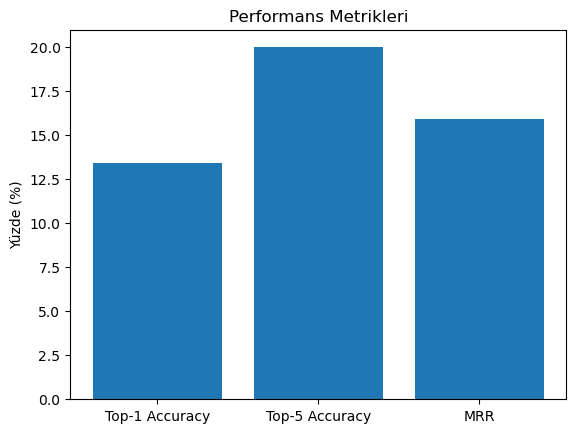

In [30]:
# Visualize results
plt.bar(['Top-1 Accuracy', 'Top-5 Accuracy', 'MRR'], [top1_accuracy, top5_accuracy, mrr])
plt.title('Performans Metrikleri')
plt.ylabel('Yüzde (%)')
plt.show()

### Method 2: nomic-embed-text-v1

In [32]:
# Load model
start_time = time.time()
model_2 = SentenceTransformer("nomic-ai/nomic-embed-text-v1", trust_remote_code=True)
model_loading_time_2 = time.time() - start_time
print(f"Model loading time: {model_loading_time_2:.2f} s")

# Compute embeddings
start_time = time.time()
question_embeddings_2 = model_2.encode(questions, batch_size=32, show_progress_bar=True)
answer_embeddings_2 = model_2.encode(answers, batch_size=32, show_progress_bar=True)
embedding_time_2 = time.time() - start_time
print(f"Embedding time: {embedding_time_2:.2f} s")

# Compute similarity
start_time = time.time()
similarities_2 = cosine_similarity(question_embeddings_2, answer_embeddings_2)
similarity_time_2 = time.time() - start_time
print(f"Similarity time: {similarity_time_2:.2f} s")

# Top-K results
def get_top_k_indices(similarities, k):
    return np.argsort(similarities, axis=1)[:, -k:][:, ::-1]

start_time = time.time()
top1_results_2 = get_top_k_indices(similarities_2, 1)
top5_results_2 = get_top_k_indices(similarities_2, 5)
top_k_time_2 = time.time() - start_time
print(f"Top-K time: {top_k_time_2:.2f} s")

# Performance metrics
def calculate_accuracy(top_k_results, correct_answers_indices, k):
    correct_count = sum(correct_answers_indices[i] in top_k[:k] for i, top_k in enumerate(top_k_results))
    return correct_count / len(correct_answers_indices) * 100

def calculate_mrr(top_k_results, correct_answers_indices):
    mrr = 0
    for i, top_k in enumerate(top_k_results):
        if correct_answers_indices[i] in top_k:
            rank = top_k.tolist().index(correct_answers_indices[i]) + 1
            mrr += 1 / rank
    return mrr / len(correct_answers_indices) * 100

correct_answers_indices = list(range(len(questions)))

# Timing for performance measurement
start_time = time.time()
top1_accuracy_2 = calculate_accuracy(top1_results_2, correct_answers_indices, k=1)
top5_accuracy_2 = calculate_accuracy(top5_results_2, correct_answers_indices, k=5)
mrr_2 = calculate_mrr(top5_results_2, correct_answers_indices)
performance_time_2 = time.time() - start_time

# Performance results
print(f"Top-1 Accuracy: {top1_accuracy_2:.2f}%")
print(f"Top-5 Accuracy: {top5_accuracy_2:.2f}%")
print(f"MRR: {mrr_2:.2f}%")
print(f"Metric computation time: {performance_time_2:.2f} s")

# Store all results
results_2 = {
    "Model": "nomic-embed-text-v1",
    "Embedding Time": embedding_time_2,
    "Similarity Time": similarity_time_2,
    "Similarities": similarities_2.tolist(),  # similarity scores
    "Correct Answers Indices": correct_answers_indices,  # correct answer indices
    "Top-K Time": top_k_time_2,
    "Top-1 Accuracy": top1_accuracy_2,
    "Top-5 Accuracy": top5_accuracy_2,
    "MRR": mrr_2
}

# Save with pickle
import pickle
with open("nomic-embed-text-v1", "wb") as pickle_file:
    pickle.dump(results_2, pickle_file)

print("Results saved.")

Model loading time: 4.39 s


Embedding time: 316.33 s
Similarity time: 0.03 s
Top-K time: 0.35 s
Top-1 Accuracy: 45.70%
Top-5 Accuracy: 58.85%
MRR: 50.67%
Metric computation time: 0.02 s
Results saved.


In [11]:
def calculate_precision_recall(top_k_results, correct_answers_indices, k):
    correct = sum(correct_answers_indices[i] in top_k[:k] for i, top_k in enumerate(top_k_results))
    precision = correct / len(top_k_results)
    recall = correct / len(correct_answers_indices)
    return precision * 100, recall * 100

precision, recall = calculate_precision_recall(top5_results_2, correct_answers_indices, k=5)
print(f"Precision: {precision:.2f}%, Recall: {recall:.2f}%")

Precision: 58.85%, Recall: 58.85%


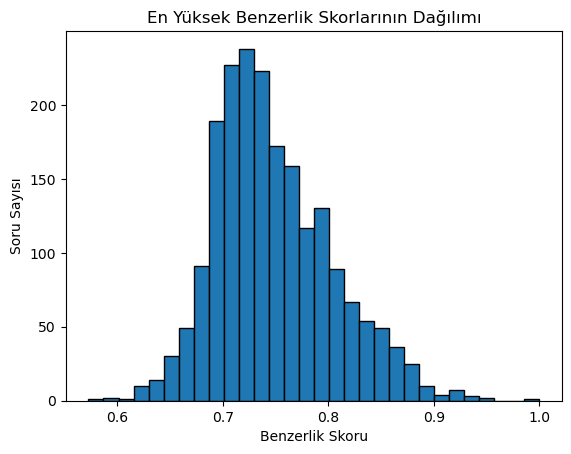

In [13]:
import matplotlib.pyplot as plt
max_scores = similarities_2.max(axis=1)
plt.hist(max_scores, bins=30, edgecolor="black")
plt.title("En Yüksek Benzerlik Skorlarının Dağılımı")
plt.xlabel("Benzerlik Skoru")
plt.ylabel("Soru Sayısı")
plt.show()

In [34]:
incorrect_indices = [i for i, top1 in enumerate(top1_results_2) if correct_answers_indices[i] not in top1]
print(f"Number of wrongly retrieved questions: {len(incorrect_indices)}")

Number of wrongly retrieved questions: 1086


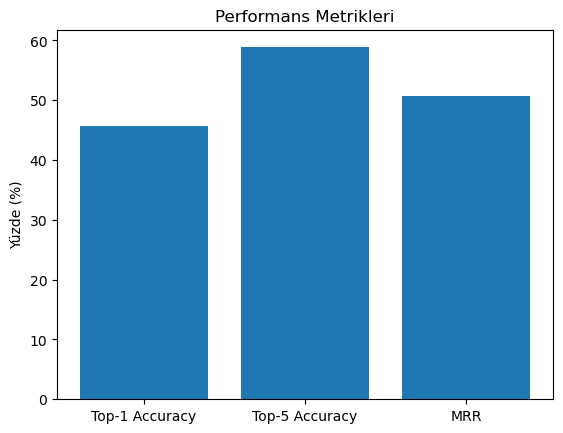

In [17]:
# Visualize results
plt.bar(['Top-1 Accuracy', 'Top-5 Accuracy', 'MRR'], [top1_accuracy_2, top5_accuracy_2, mrr_2])
plt.title('Performans Metrikleri')
plt.ylabel('Yüzde (%)')
plt.show()

### Method 3: gte-large

In [36]:
# Select device ('cuda' if a GPU is available, otherwise 'cpu')
device = "cuda" if torch.cuda.is_available() else "cpu"

# Load model
start_time = time.time()
model_name_3 = "thenlper/gte-large"
model_3 = SentenceTransformer(model_name_3, device=device)
model_loading_time_3 = time.time() - start_time
print(f"Model loading time: {model_loading_time_3:.2f} s")

# Compute embeddings
def extract_embeddings(model, texts, batch_size=32):
    """
    Computes embeddings for questions or answers.
    """
    embeddings = model.encode(texts, batch_size=batch_size, show_progress_bar=True)
    return np.array(embeddings)

start_time = time.time()
#question_embeddings_3 = extract_embeddings(model_3, questions, batch_size=32, show_progress_bar=True)
question_embeddings_3 = model_3.encode(questions, batch_size=32, show_progress_bar=True)

#answer_embeddings_3 = extract_embeddings(model_3, answers, batch_size=32, show_progress_bar=True)
answer_embeddings_3 = model_3.encode(answers, batch_size=32, show_progress_bar=True)

embedding_time_3 = time.time() - start_time
print(f"Embedding time: {embedding_time_3:.2f} s")

# Compute similarity
start_time = time.time()
similarities_3 = cosine_similarity(question_embeddings_3, answer_embeddings_3)
similarity_time_3 = time.time() - start_time
print(f"Similarity time: {similarity_time_3:.2f} s")

# Top-K results
def get_top_k_indices(similarities, k):
    """
    Returns the Top-K indices of the similarity scores.
    """
    return np.argsort(similarities, axis=1)[:, -k:][:, ::-1]

start_time = time.time()
top1_results_3 = get_top_k_indices(similarities_3, 1)
top5_results_3 = get_top_k_indices(similarities_3, 5)
top_k_time_3 = time.time() - start_time
print(f"Top-K time: {top_k_time_3:.2f} s")

# Performance metrics
def calculate_accuracy(top_k_results, correct_answers_indices, k):
    """
    Computes Top-K accuracy.
    """
    correct_count = sum(correct_answers_indices[i] in top_k[:k] for i, top_k in enumerate(top_k_results))
    return correct_count / len(correct_answers_indices) * 100

def calculate_mrr(top_k_results, correct_answers_indices):
    """
    Computes the Mean Reciprocal Rank (MRR).
    """
    mrr = 0
    for i, top_k in enumerate(top_k_results):
        if correct_answers_indices[i] in top_k:
            rank = top_k.tolist().index(correct_answers_indices[i]) + 1
            mrr += 1 / rank
    return mrr / len(correct_answers_indices) * 100

correct_answers_indices = list(range(len(questions)))

# Compute performance metrics
top1_accuracy_3 = calculate_accuracy(top1_results_3, correct_answers_indices, k=1)
top5_accuracy_3 = calculate_accuracy(top5_results_3, correct_answers_indices, k=5)
mrr_3 = calculate_mrr(top5_results_3, correct_answers_indices)

# Results
print(f"Top-1 Accuracy: {top1_accuracy_3:.2f}%")
print(f"Top-5 Accuracy: {top5_accuracy_3:.2f}%")
print(f"MRR: {mrr_3:.2f}%")

# Store all times and results in a dictionary
results_3 = {
    "Model": "gte-large",
    "Embedding Time": embedding_time_3,
    "Similarity Time": similarity_time_3,
    "Similarities": similarities_3.tolist(),  # similarity scores
    "Correct Answers Indices": correct_answers_indices,  # correct answer indices
    "Top-K Time": top_k_time_3,
    "Top-1 Accuracy": top1_accuracy_3,
    "Top-5 Accuracy": top5_accuracy_3,
    "MRR": mrr_3
}
print(results_3)

# Save with pickle
import pickle
with open("gte-large", "wb") as pickle_file:
    pickle.dump(results_3, pickle_file)

print("Results saved.")

Model loading time: 3.50 s


Embedding time: 712.45 s
Similarity time: 0.04 s
Top-K time: 0.35 s
Top-1 Accuracy: 41.65%
Top-5 Accuracy: 55.30%
MRR: 46.82%


In [53]:
incorrect_indices = [i for i, top1 in enumerate(top1_results_3) if correct_answers_indices[i] not in top1]
print(f"Number of wrongly retrieved questions: {len(incorrect_indices)}")

Number of wrongly retrieved questions: 1167


### Method 4: bge-m3

In [9]:
# Check GPU or CPU usage
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Model will run on {device}.")

# Load model
start_time = time.time()
model_4 = BGEM3FlagModel('BAAI/bge-m3', use_fp16=True, device=device)
model_loading_time_4 = time.time() - start_time
print(f"Model loading time: {model_loading_time_4:.2f} s")

# Compute embeddings
def extract_embeddings(model, texts, batch_size=12, max_length=8192):
    """
    Computes embeddings for questions or answers.
    """
    embeddings = model.encode(texts, batch_size=batch_size, max_length=max_length)['dense_vecs']
    return np.array(embeddings)

start_time = time.time()
question_embeddings_4 = extract_embeddings(model_4, questions)
answer_embeddings_4 = extract_embeddings(model_4, answers)
embedding_time_4 = time.time() - start_time
print(f"Embedding time: {embedding_time_4:.2f} s")

# Compute similarity
start_time = time.time()
similarities_4 = cosine_similarity(question_embeddings_4, answer_embeddings_4)
similarity_time_4 = time.time() - start_time
print(f"Similarity time: {similarity_time_4:.2f} s")

# Top-K results
def get_top_k_indices(similarities, k):
    """
    Returns the Top-K indices of the similarity scores.
    """
    return similarities.argsort(axis=1)[:, -k:][:, ::-1]

start_time = time.time()
top1_results_4 = get_top_k_indices(similarities_4, 1)
top5_results_4 = get_top_k_indices(similarities_4, 5)
top_k_time_4 = time.time() - start_time
print(f"Top-K time: {top_k_time_4:.2f} s")

# Performance metrics
def calculate_accuracy(top_k_results, correct_answers_indices, k):
    """
    Computes Top-K accuracy.
    """
    correct_count = sum(correct_answers_indices[i] in top_k[:k] for i, top_k in enumerate(top_k_results))
    return correct_count / len(correct_answers_indices) * 100

def calculate_mrr(top_k_results, correct_answers_indices):
    """
    Computes the Mean Reciprocal Rank (MRR).
    """
    mrr = 0
    for i, top_k in enumerate(top_k_results):
        if correct_answers_indices[i] in top_k:
            rank = top_k.tolist().index(correct_answers_indices[i]) + 1
            mrr += 1 / rank
    return mrr / len(correct_answers_indices) * 100

correct_answers_indices = list(range(len(questions)))

# Compute performance metrics
top1_accuracy_4 = calculate_accuracy(top1_results_4, correct_answers_indices, k=1)
top5_accuracy_4 = calculate_accuracy(top5_results_4, correct_answers_indices, k=5)
mrr_4 = calculate_mrr(top5_results_4, correct_answers_indices)

# Results
print(f"Top-1 Accuracy: {top1_accuracy_4:.2f}%")
print(f"Top-5 Accuracy: {top5_accuracy_4:.2f}%")
print(f"MRR: {mrr_4:.2f}%")

# Store all times and results in a dictionary
results_4 = {
    "Model": "bge-m3",
    "Embedding Time": embedding_time_4,
    "Similarity Time": similarity_time_4,
    "Similarities": similarities_4.tolist(),  # similarity scores
    "Correct Answers Indices": correct_answers_indices,  # correct answer indices
    "Top-K Time": top_k_time_4,
    "Top-1 Accuracy": top1_accuracy_4,
    "Top-5 Accuracy": top5_accuracy_4,
    "MRR": mrr_4
}
print(results_4)

Model will run on cpu.


Model loading time: 1.33 s


Embedding time: 411.83 s
Similarity time: 0.05 s
Top-K time: 0.35 s
Top-1 Accuracy: 76.10%
Top-5 Accuracy: 87.80%
MRR: 80.85%


In [23]:
incorrect_indices1 = [i for i, top1 in enumerate(top1_results_4) if correct_answers_indices[i] not in top1]
print(f"Number of wrongly retrieved questions Top 1: {len(incorrect_indices1)}")
incorrect_indices2 = [i for i, top1 in enumerate(top5_results_4) if correct_answers_indices[i] not in top1]
print(f"Number of wrongly retrieved questions Top 5: {len(incorrect_indices2)}")

Number of wrongly retrieved questions Top 1: 478
Number of wrongly retrieved questions Top 5: 244


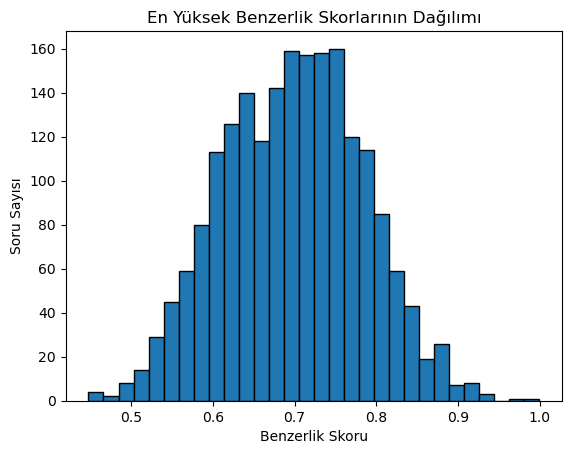

In [25]:
import matplotlib.pyplot as plt
max_scores = similarities_4.max(axis=1)
plt.hist(max_scores, bins=30, edgecolor="black")
plt.title("En Yüksek Benzerlik Skorlarının Dağılımı")
plt.xlabel("Benzerlik Skoru")
plt.ylabel("Soru Sayısı")
plt.show()

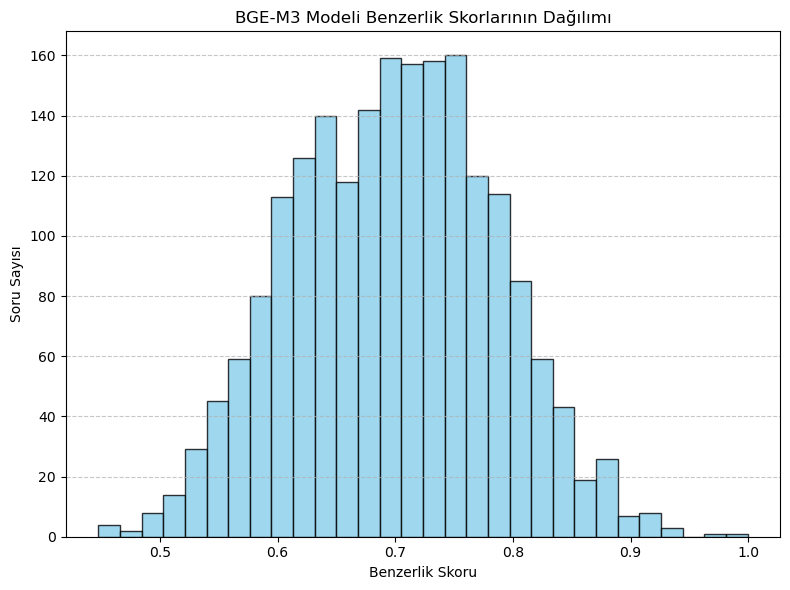

In [31]:
# Get highest similarity scores
max_scores = similarities_4.max(axis=1)

# Histogram
plt.figure(figsize=(8, 6))
plt.hist(max_scores, bins=30, edgecolor='black', color='skyblue', alpha=0.8)
plt.title('BGE-M3 Modeli Benzerlik Skorlarının Dağılımı')
plt.xlabel('Benzerlik Skoru')
plt.ylabel('Soru Sayısı')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

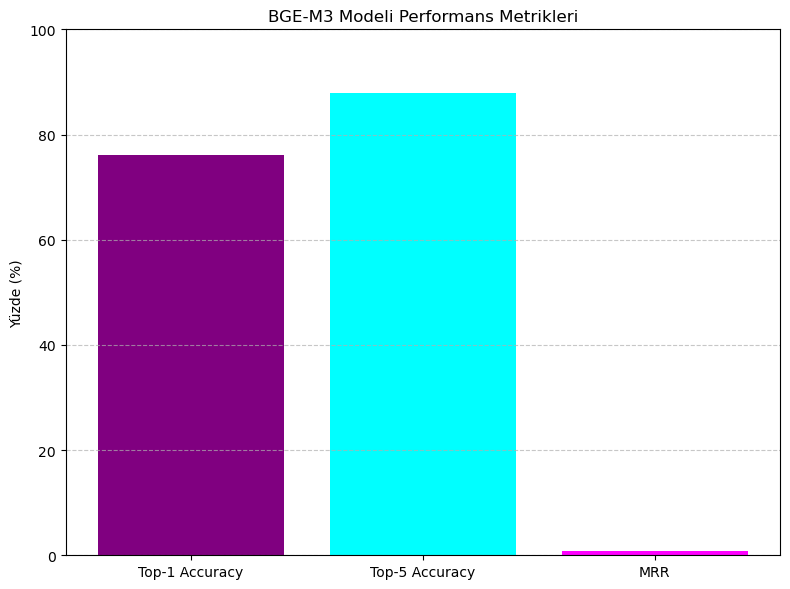

In [29]:
# Performance metrics and labels
metrics = [top1_accuracy_4, top5_accuracy_4, mrr_4]
metric_labels = ['Top-1 Accuracy', 'Top-5 Accuracy', 'MRR']

# Bar chart
plt.figure(figsize=(8, 6))
plt.bar(metric_labels, metrics, color=['purple', 'cyan', 'magenta'])
plt.title('BGE-M3 Modeli Performans Metrikleri')
plt.ylabel('Yüzde (%)')
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [11]:
import pickle

# Store results of a single model
with open("bge_m3_results.pkl", "wb") as pickle_file:
    pickle.dump(results_4, pickle_file)

In [15]:
# Load results of a single model from pickle
with open("bge_m3_results.pkl", "rb") as pickle_file:
    loaded_results = pickle.load(pickle_file)

# Print results
print(loaded_results)

{'Model': 'bge-m3', 'Embedding Time': 426.29352164268494, 'Similarity Time': 0.05959486961364746, 'Top-K Time': 0.36300182342529297, 'Top-1 Accuracy': 76.1, 'Top-5 Accuracy': 87.8, 'MRR': 0.8084999999999998}


### Method 5: bert-base-turkish-uncased

In [13]:
# GPU or CPU check
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Model will run on {device}.")

# Load model and tokenizer
start_time = time.time()
tokenizer = AutoTokenizer.from_pretrained("dbmdz/bert-base-turkish-uncased")
model_5 = AutoModel.from_pretrained("dbmdz/bert-base-turkish-uncased").to(device)
model_loading_time_5 = time.time() - start_time
print(f"Model loading time: {model_loading_time_5:.2f} s")

# Compute embeddings
def get_embedding_batch(sentences, batch_size=16, max_length=512):
    embeddings = []
    for i in range(0, len(sentences), batch_size):
        batch = sentences[i:i + batch_size]
        inputs = tokenizer(batch, padding=True, truncation=True, return_tensors="pt", max_length=max_length).to(device)
        with torch.no_grad():
            batch_embeddings = model_5(**inputs).last_hidden_state.mean(dim=1)  # Mean pooling
        embeddings.append(batch_embeddings.cpu())  # Move from GPU to CPU
    return torch.cat(embeddings, dim=0)

start_time = time.time()
question_embeddings_5 = get_embedding_batch(questions)
answer_embeddings_5 = get_embedding_batch(answers)
embedding_time_5 = time.time() - start_time
print(f"Embedding time: {embedding_time_5:.2f} s")

# Compute similarity
start_time = time.time()
similarities_5 = cosine_similarity(question_embeddings_5.numpy(), answer_embeddings_5.numpy())
similarity_time_5 = time.time() - start_time
print(f"Similarity time: {similarity_time_5:.2f} s")

# Top-K results
def get_top_k_indices(similarity_matrix, k):
    return np.argsort(similarity_matrix, axis=1)[:, -k:][:, ::-1]

start_time = time.time()
top1_results_5 = get_top_k_indices(similarities_5, 1)
top5_results_5 = get_top_k_indices(similarities_5, 5)
top_k_time_5 = time.time() - start_time
print(f"Top-K time: {top_k_time_5:.2f} s")

# Performance metrics
def calculate_accuracy(top_k_results, correct_answers_indices, k):
    correct_count = sum(correct_answers_indices[i] in top_k[:k] for i, top_k in enumerate(top_k_results))
    return correct_count / len(correct_answers_indices) * 100

def calculate_mrr(top_k_results, correct_answers_indices):
    mrr = 0
    for i, top_k in enumerate(top_k_results):
        if correct_answers_indices[i] in top_k:
            rank = top_k.tolist().index(correct_answers_indices[i]) + 1
            mrr += 1 / rank
    return mrr / len(correct_answers_indices) * 100

correct_answers_indices = list(range(len(questions)))

# Compute performance metrics
top1_accuracy_5 = calculate_accuracy(top1_results_5, correct_answers_indices, k=1)
top5_accuracy_5 = calculate_accuracy(top5_results_5, correct_answers_indices, k=5)
mrr_5 = calculate_mrr(top5_results_5, correct_answers_indices)

# Print results
print(f"Top-1 Accuracy: {top1_accuracy_5:.2f}%")
print(f"Top-5 Accuracy: {top5_accuracy_5:.2f}%")
print(f"MRR: {mrr_5:.2f}%")

# Store all results
results_5 = {
    "Model": "bert-base-turkish-uncased",
    "Embedding Time": embedding_time_5,
    "Similarity Time": similarity_time_5,
    "Similarities": similarities_5.tolist(),  # similarity scores
    "Correct Answers Indices": correct_answers_indices,  # correct answer indices
    "Top-K Time": top_k_time_5,
    "Top-1 Accuracy": top1_accuracy_5,
    "Top-5 Accuracy": top5_accuracy_5,
    "MRR": mrr_5
}

# Save with pickle
import pickle
with open("bert_turkish_results.pkl", "wb") as pickle_file:
    pickle.dump(results_5, pickle_file)

print("Results saved.")

Model will run on cpu.


Model loading time: 1.21 s
Embedding time: 293.97 s
Similarity time: 0.03 s
Top-K time: 0.34 s
Top-1 Accuracy: 21.30%
Top-5 Accuracy: 33.50%
MRR: 0.26%
Results saved.


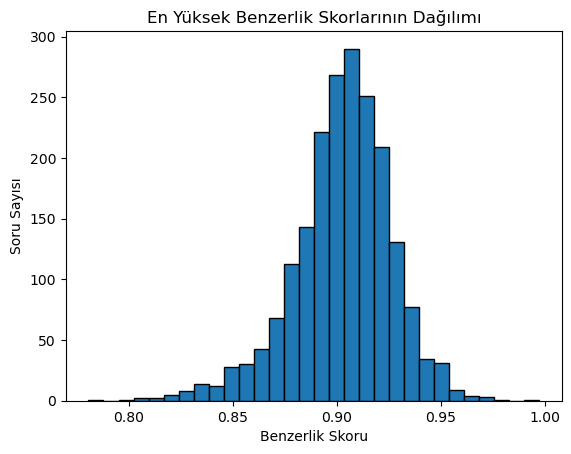

In [15]:
import matplotlib.pyplot as plt
max_scores = similarities_5.max(axis=1)
plt.hist(max_scores, bins=30, edgecolor="black")
plt.title("En Yüksek Benzerlik Skorlarının Dağılımı")
plt.xlabel("Benzerlik Skoru")
plt.ylabel("Soru Sayısı")
plt.show()

In [38]:
incorrect_indices1 = [i for i, top1 in enumerate(top1_results_5) if correct_answers_indices[i] not in top1]
print(f"Number of wrongly retrieved questions Top 1: {len(incorrect_indices1)}")
incorrect_indices2 = [i for i, top1 in enumerate(top5_results_5) if correct_answers_indices[i] not in top1]
print(f"Number of wrongly retrieved questions Top 5: {len(incorrect_indices2)}")

Number of wrongly retrieved questions Top 1: 1574
Number of wrongly retrieved questions Top 5: 1330


## Ensemble Methods

- **Weighted average** of the similarity matrices (weights from average similarity, Top-1 or Top-5 accuracy)
- **Majority voting** over each model's Top-1 prediction
- **Max similarity** across models

## Load the saved similarity matrices of all models

In [17]:
from collections import Counter
import pickle

In [19]:
# 1. Load model results
with open("all-MiniLM-L12-v2", "rb") as file:
    all_MiniLM_results = pickle.load(file)

with open("nomic-embed-text-v1", "rb") as file:
    nomic_embed_text_results = pickle.load(file)

with open("gte-large", "rb") as file:
    gte_large_results = pickle.load(file)

with open("bge_m3_results.pkl", "rb") as file:
    bge_m3_results = pickle.load(file)
    
with open("bert_turkish_results.pkl", "rb") as file:
    bert_turkish_results = pickle.load(file)

In [23]:
# Organize similarity scores of the models
similarities = {
    "all-MiniLM-L12-v2": np.array(all_MiniLM_results["Similarities"]),
    "nomic-embed-text-v1": np.array(nomic_embed_text_results["Similarities"]),
    "gte-large": np.array(gte_large_results["Similarities"]),
    "bge-m3": np.array(bge_m3_results["Similarities"]),
    "bert-base-turkish-uncased": np.array(bert_turkish_results["Similarities"]),
}

# Find indices of correct answers
correct_answers_indices = list(range(len(similarities["all-MiniLM-L12-v2"])))


In [25]:
# Weights
weights = {
    "all-MiniLM-L12-v2": 0.2,
    "nomic-embed-text-v1": 0.2,
    "gte-large": 0.2,
    "bge-m3": 0.2,
    "bert-base-turkish-uncased": 0.2,
}

# Weighted similarity
weighted_similarities = sum(weights[model] * similarities[model] for model in similarities.keys())

# Compute Top-K results
weighted_top1 = get_top_k_indices(weighted_similarities, 1)
weighted_top5 = get_top_k_indices(weighted_similarities, 5)


In [27]:
from collections import Counter

# Combine Top-1 results
top1_votes = np.array([similarities[model].argmax(axis=1) for model in similarities.keys()])
majority_top1 = [Counter(row).most_common(1)[0][0] for row in top1_votes.T]

# A similar approach can be used for Top-5
majority_top5 = get_top_k_indices(weighted_similarities, 5)


In [33]:
print("Weighted Top-5 Results (First 5):", weighted_top5[:5])
print("Majority Top-5 Results (First 5):", majority_top5[:5])
print("Correct Answers Indices (First 5):", correct_answers_indices[:5])

Weighted Top-5 Results (First 5): [[1689  127 1459    0 1581]
 [1753  712 1527 1254  620]
 [   2   47 1019  598  865]
 [ 617 1537 1386  107 1795]
 [ 496    4  330  794 1235]]
Majority Top-5 Results (First 5): [[1689  127 1459    0 1581]
 [1753  712 1527 1254  620]
 [   2   47 1019  598  865]
 [ 617 1537 1386  107 1795]
 [ 496    4  330  794 1235]]
Correct Answers Indices (First 5): [0, 1, 2, 3, 4]


In [35]:
# Check whether correct answers are in the Top-5 results
for i in range(5):  # For the first 5 questions
    print(f"Question {i + 1}:")
    print(f"  Weighted Top-5: {weighted_top5[i]}")
    print(f"  Correct Answer Index: {correct_answers_indices[i]}")
    print(f"  Correct Answer in Top-5: {correct_answers_indices[i] in weighted_top5[i]}")


Question 1:
  Weighted Top-5: [1689  127 1459    0 1581]
  Correct Answer Index: 0
  Correct Answer in Top-5: True
Question 2:
  Weighted Top-5: [1753  712 1527 1254  620]
  Correct Answer Index: 1
  Correct Answer in Top-5: False
Question 3:
  Weighted Top-5: [   2   47 1019  598  865]
  Correct Answer Index: 2
  Correct Answer in Top-5: True
Question 4:
  Weighted Top-5: [ 617 1537 1386  107 1795]
  Correct Answer Index: 3
  Correct Answer in Top-5: False
Question 5:
  Weighted Top-5: [ 496    4  330  794 1235]
  Correct Answer Index: 4
  Correct Answer in Top-5: True


In [37]:
for i in range(5):  # For the first 5 questions
    if correct_answers_indices[i] in weighted_top5[i]:
        rank = list(weighted_top5[i]).index(correct_answers_indices[i]) + 1
        print(f"Question {i + 1}: correct answer is at rank {rank}.")
    else:
        print(f"Question {i + 1}: correct answer is not in the Top-5.")


Question 1: correct answer is at rank 4.
Question 2: correct answer is not in the Top-5.
Question 3: correct answer is at rank 1.
Question 4: correct answer is not in the Top-5.
Question 5: correct answer is at rank 2.


### Determining the Weights

Weights based on average similarity scores

In this method:

- Models with a higher average similarity score get a higher weight.
- The weights sum to 1.

In [109]:
# Compute average similarity scores
average_similarities = {
    model: similarities[model].mean() for model in similarities.keys()
}

# Find total similarity scores
total_similarity = sum(average_similarities.values())

# Compute weights (proportional)
weights = {
    model: average_similarities[model] / total_similarity for model in similarities.keys()
}

# Print weights
print("Weights (based on similarity ratios):")
for model, weight in weights.items():
    print(f"{model}: {weight:.4f}")


Weights (based on similarity ratios):
all-MiniLM-L12-v2: 0.1461
nomic-embed-text-v1: 0.1801
gte-large: 0.2860
bge-m3: 0.1182
bert-base-turkish-uncased: 0.2697


In [123]:
for model in average_similarities.keys():
    print(f"{model}: Average similarity score = {average_similarities[model]:.4f}, Weight = {weights[model]:.4f}")

all-MiniLM-L12-v2: Average similarity score = 0.4299, Weight = 0.1461
nomic-embed-text-v1: Average similarity score = 0.5300, Weight = 0.1801
gte-large: Average similarity score = 0.8416, Weight = 0.2860
bge-m3: Average similarity score = 0.3478, Weight = 0.1182
bert-base-turkish-uncased: Average similarity score = 0.7937, Weight = 0.2697


b. Weights based on Top-1 or Top-5 performance

In [81]:
import pickle

# Define pickle file paths (check paths)
model_files = {
    "all-MiniLM-L12-v2": "all-MiniLM-L12-v2",
    "nomic-embed-text-v1": "nomic-embed-text-v1",
    "gte-large": "gte-large",
    "bge-m3": "bge_m3_results.pkl",
    "bert-base-turkish-uncased": "bert_turkish_results.pkl",
}

# Dictionary for performance metrics
model_performance = {}

# Read pickle files to get Top-1 accuracy and other info
for model, file in model_files.items():
    try:
        with open(file, "rb") as f:
            results = pickle.load(f)
            model_performance[model] = {
                "Top-1 Accuracy": results["Top-1 Accuracy"],
                "Top-5 Accuracy": results["Top-5 Accuracy"],
                "MRR": results["MRR"],
            }
    except FileNotFoundError:
        print(f"File not found: {file}")
        continue

# Compute overall performance (using Top-1 accuracy)
total_top1_accuracy = sum([metrics["Top-1 Accuracy"] for metrics in model_performance.values()])

# Compute weights (between 0 and 1)
weights = {model: metrics["Top-1 Accuracy"] / total_top1_accuracy for model, metrics in model_performance.items()}

# Print results
print("Model performance and weights:")
print("Model".ljust(25), "Top-1 Accuracy (%)".ljust(20), "Weight".ljust(10), "Weight (%)")
weights_list_top1 = []
for model, metrics in model_performance.items():
    weight = weights[model]
    weights_list_top1.append(weight)  # Append weights to list
    print(
        f"{model.ljust(25)} {metrics['Top-1 Accuracy']:.2f}".ljust(20),
        f"{weight:.4f}".ljust(10),
        f"{weight * 100:.2f}%"
    )

# Store weights in a list
print("\nWeight list (values between 0 and 1):", weights_list_top1)


Model performance and weights:
Model                     Top-1 Accuracy (%)   Weight     Weight (%)
all-MiniLM-L12-v2         13.45 0.0679     6.79%
nomic-embed-text-v1       45.70 0.2306     23.06%
gte-large                 41.65 0.2101     21.01%
bge-m3                    76.10 0.3840     38.40%
bert-base-turkish-uncased 21.30 0.1075     10.75%

Weight list (values between 0 and 1): [0.06786074672048437, 0.23057517658930377, 0.2101412714429869, 0.3839556004036327, 0.10746720484359235]


In [88]:
# Weighted similarity (using weights_list_top1)
weighted_similarities = sum(
    weight * similarities[model] for weight, model in zip(weights_list_top1, model_files.keys())
)

# Compute Top-K results
weighted_top1 = get_top_k_indices(weighted_similarities, 1)
weighted_top5 = get_top_k_indices(weighted_similarities, 5)

# Compute performance metrics
weighted_top1_accuracy = calculate_accuracy(weighted_top1, correct_answers_indices, k=1)
weighted_top5_accuracy = calculate_accuracy(weighted_top5, correct_answers_indices, k=5)
weighted_mrr = calculate_mrr(weighted_top5, correct_answers_indices)

# Print results
print("Weighted average performance (with weights_list_top1):")
print(f"Top-1 Accuracy: {weighted_top1_accuracy:.2f}%")
print(f"Top-5 Accuracy: {weighted_top5_accuracy:.2f}%")
print(f"MRR: {weighted_mrr:.2f}%")

Weighted average performance (with weights_list_top1):
Top-1 Accuracy: 71.50%
Top-5 Accuracy: 83.25%
MRR: 0.76%


In [83]:
import pickle

# Define pickle file paths (check paths)
model_files = {
    "all-MiniLM-L12-v2": "all-MiniLM-L12-v2",
    "nomic-embed-text-v1": "nomic-embed-text-v1",
    "gte-large": "gte-large",
    "bge-m3": "bge_m3_results.pkl",
    "bert-base-turkish-uncased": "bert_turkish_results.pkl",
}

# Dictionary for performance metrics
model_performance = {}

# Read pickle files to get Top-1 accuracy and other info
for model, file in model_files.items():
    try:
        with open(file, "rb") as f:
            results = pickle.load(f)
            model_performance[model] = {
                "Top-1 Accuracy": results["Top-1 Accuracy"],
                "Top-5 Accuracy": results["Top-5 Accuracy"],
                "MRR": results["MRR"],
            }
    except FileNotFoundError:
        print(f"File not found: {file}")
        continue

# Compute overall performance (using Top-1 accuracy)
total_top5_accuracy = sum([metrics["Top-5 Accuracy"] for metrics in model_performance.values()])

# Compute weights (between 0 and 1)
weights = {model: metrics["Top-5 Accuracy"] / total_top1_accuracy for model, metrics in model_performance.items()}

# Print results
print("Model performance and weights:")
print("Model".ljust(25), "Top-5 Accuracy (%)".ljust(20), "Weight".ljust(10), "Weight (%)")
weights_list_top5 = []
for model, metrics in model_performance.items():
    weight = weights[model]
    weights_list_top5.append(weight)  # Append weights to list
    print(
        f"{model.ljust(25)} {metrics['Top-5 Accuracy']:.2f}".ljust(20),
        f"{weight:.4f}".ljust(10),
        f"{weight * 100:.2f}%"
    )

# Store weights in a list
print("\nWeight list (values between 0 and 1):", weights_list_top5)


Model performance and weights:
Model                     Top-5 Accuracy (%)   Weight     Weight (%)
all-MiniLM-L12-v2         20.00 0.1009     10.09%
nomic-embed-text-v1       58.85 0.2969     29.69%
gte-large                 55.30 0.2790     27.90%
bge-m3                    87.80 0.4430     44.30%
bert-base-turkish-uncased 33.50 0.1690     16.90%

Weight list (values between 0 and 1): [0.10090817356205853, 0.2969223007063572, 0.27901109989909184, 0.44298688193743696, 0.16902119071644806]


In [125]:
# Weighted similarity (using weights_list_top5)
weighted_similarities = sum(
    weight * similarities[model] for weight, model in zip(weights_list_top5, model_files.keys())
)

# Compute Top-K results
weighted_top1_2 = get_top_k_indices(weighted_similarities, 1)
weighted_top5_2 = get_top_k_indices(weighted_similarities, 5)

# Compute performance metrics
weighted_top1_accuracy_2 = calculate_accuracy(weighted_top1_2, correct_answers_indices, k=1)
weighted_top5_accuracy_2 = calculate_accuracy(weighted_top5_2, correct_answers_indices, k=5)
weighted_mrr_2 = calculate_mrr(weighted_top5_2, correct_answers_indices)

# Print results
print("Weighted average performance (with weights_list_top5):")
print(f"Top-1 Accuracy: {weighted_top1_accuracy_2:.2f}%")
print(f"Top-5 Accuracy: {weighted_top5_accuracy_2:.2f}%")
print(f"MRR: {weighted_mrr_2:.2f}%")

Weighted average performance (with weights_list_top5):
Top-1 Accuracy: 69.85%
Top-5 Accuracy: 82.50%
MRR: 74.81%


### Majority Voting and Comparison

In [96]:
import pickle
import numpy as np
from collections import Counter

# Define pickle file paths
model_files = {
    "all-MiniLM-L12-v2": "all-MiniLM-L12-v2",
    "nomic-embed-text-v1": "nomic-embed-text-v1",
    "gte-large": "gte-large",
    "bge-m3": "bge_m3_results.pkl",
    "bert-base-turkish-uncased": "bert_turkish_results.pkl",
}

# Dictionaries to store model info
model_performance = {}
similarities = {}

# Read pickle files to get info
for model, file in model_files.items():
    with open(file, "rb") as f:
        results = pickle.load(f)
        model_performance[model] = {
            "Top-1 Accuracy": results["Top-1 Accuracy"],
            "Top-5 Accuracy": results["Top-5 Accuracy"],
            "MRR": results["MRR"],
        }
        similarities[model] = np.array(results["Similarities"])  # store similarity scores

# Correct answers indices
correct_answers_indices = list(range(len(next(iter(similarities.values())))))

# Apply ensemble methods
# (a) Weighted average
weights = {model: metrics["Top-1 Accuracy"] / sum(m["Top-1 Accuracy"] for m in model_performance.values())
           for model, metrics in model_performance.items()}
weighted_similarities = sum(weights[model] * similarities[model] for model in similarities.keys())
weighted_top1 = np.argsort(weighted_similarities, axis=1)[:, -1:][:, ::-1]
weighted_top5 = np.argsort(weighted_similarities, axis=1)[:, -5:][:, ::-1]

# (a.2) Weighted average - Top5
weights_2 = {model: metrics["Top-5 Accuracy"] / sum(m["Top-5 Accuracy"] for m in model_performance.values())
           for model, metrics in model_performance.items()}
weighted_similarities_2 = sum(weights_2[model] * similarities[model] for model in similarities.keys())
weighted_top1_2 = np.argsort(weighted_similarities_2, axis=1)[:, -1:][:, ::-1]
weighted_top5_2 = np.argsort(weighted_similarities_2, axis=1)[:, -5:][:, ::-1]

# (b) Majority voting
top1_votes = {model: np.argsort(similarities[model], axis=1)[:, -1:][:, ::-1] for model in similarities.keys()}
majority_top1 = [Counter([top1_votes[model][i, 0] for model in top1_votes.keys()]).most_common(1)[0][0]
                 for i in range(len(correct_answers_indices))]
top5_votes = {model: np.argsort(similarities[model], axis=1)[:, -5:][:, ::-1] for model in similarities.keys()}
majority_top5 = []
for i in range(len(correct_answers_indices)):
    combined_votes = []
    for model in top5_votes.keys():
        combined_votes.extend(top5_votes[model][i])
    majority_top5.append([idx for idx, _ in Counter(combined_votes).most_common(5)])

# (c) Max similarity
max_similarity_top1 = np.argmax(weighted_similarities, axis=1)
max_similarity_top5 = []
for i in range(len(correct_answers_indices)):
    max_similarity_top5.append(weighted_similarities[i].argsort()[-5:][::-1])

# Compute performance
def calculate_accuracy(top_k_results, correct_answers_indices, k):
    correct = 0
    for i, top_k in enumerate(top_k_results):
        if correct_answers_indices[i] in top_k[:k]:
            correct += 1
    return (correct / len(correct_answers_indices)) * 100

def calculate_mrr(top_k_results, correct_answers_indices):
    mrr = 0
    for i, top_k in enumerate(top_k_results):
        if correct_answers_indices[i] in top_k:
            rank = list(top_k).index(correct_answers_indices[i]) + 1
            mrr += 1 / rank
    return (mrr / len(correct_answers_indices)) * 100

# Compute performance metrics
ensemble_performance = {
    "Weighted Average - Top 1": {
        "Top-1 Accuracy": calculate_accuracy(weighted_top1, correct_answers_indices, k=1),
        "Top-5 Accuracy": calculate_accuracy(weighted_top5, correct_answers_indices, k=5),
        "MRR": calculate_mrr(weighted_top5, correct_answers_indices),
    },
    "Weighted Average - Top 5": {
        "Top-1 Accuracy": calculate_accuracy(weighted_top1_2, correct_answers_indices, k=1),
        "Top-5 Accuracy": calculate_accuracy(weighted_top5_2, correct_answers_indices, k=5),
        "MRR": calculate_mrr(weighted_top5_2, correct_answers_indices),
    },
    "Majority Voting": {
        "Top-1 Accuracy": calculate_accuracy(np.array(majority_top1).reshape(-1, 1), correct_answers_indices, k=1),
        "Top-5 Accuracy": calculate_accuracy(np.array(majority_top5), correct_answers_indices, k=5),
        "MRR": calculate_mrr(np.array(majority_top5), correct_answers_indices),
    },
    "Max Similarity": {
        "Top-1 Accuracy": calculate_accuracy(np.array(max_similarity_top1).reshape(-1, 1), correct_answers_indices, k=1),
        "Top-5 Accuracy": calculate_accuracy(np.array(max_similarity_top5), correct_answers_indices, k=5),
        "MRR": calculate_mrr(np.array(max_similarity_top5), correct_answers_indices),
    }
}

# Print results
print("\nPerformance of ensemble methods:")
for method, metrics in ensemble_performance.items():
    print(f"\n{method}:")
    for metric, value in metrics.items():
        print(f"  {metric}: {value:.2f}%")



Performance of ensemble methods:

Weighted Average - Top 1:
  Top-1 Accuracy: 71.50%
  Top-5 Accuracy: 83.25%
  MRR: 76.15%

Weighted Average - Top 5:
  Top-1 Accuracy: 69.85%
  Top-5 Accuracy: 82.50%
  MRR: 74.81%

Majority Voting:
  Top-1 Accuracy: 52.25%
  Top-5 Accuracy: 68.25%
  MRR: 57.01%

Max Similarity:
  Top-1 Accuracy: 71.50%
  Top-5 Accuracy: 83.25%
  MRR: 76.15%


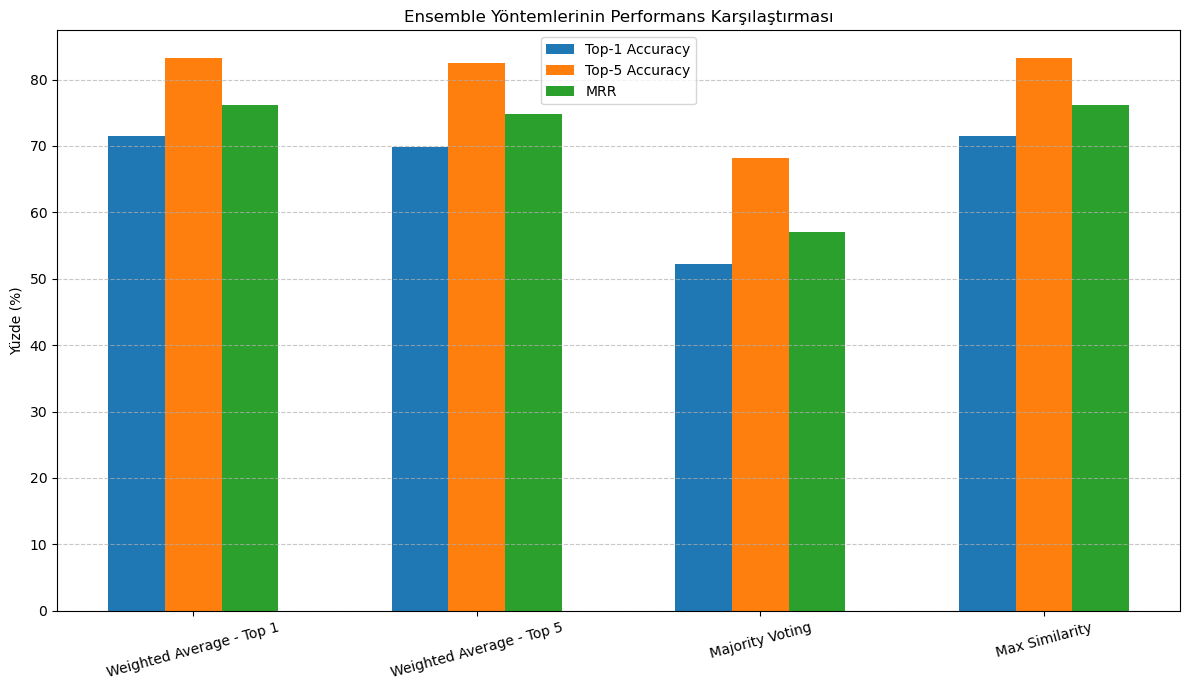

In [102]:
# Prepare performance metrics
methods = list(ensemble_performance.keys())
top1_accuracies = [ensemble_performance[method]["Top-1 Accuracy"] for method in methods]
top5_accuracies = [ensemble_performance[method]["Top-5 Accuracy"] for method in methods]
mrr_scores = [ensemble_performance[method]["MRR"] for method in methods]

# Bar charts
plt.figure(figsize=(12, 7))

x = np.arange(len(methods))
width = 0.2

# Top-1 Accuracy
plt.bar(x - width, top1_accuracies, width, label="Top-1 Accuracy")

# Top-5 Accuracy
plt.bar(x, top5_accuracies, width, label="Top-5 Accuracy")

# MRR
plt.bar(x + width, mrr_scores, width, label="MRR")

# Plot settings
plt.xticks(x, methods, rotation=15)
plt.ylabel("Yüzde (%)")
plt.title("Ensemble Yöntemlerinin Performans Karşılaştırması")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()

# Show plot
plt.show()
